# 20243788 Eunbi Cho
BTM50039 | AI for Business Management \
Individual Project

# Import Libraries and Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/KAIST/25_01/인공지능'

Mounted at /content/drive
/content/drive/MyDrive/KAIST/25_01/인공지능


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
! pip install tslearn
from sklearn.cluster import DBSCAN
from tslearn.metrics import cdist_dtw
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from matplotlib.colors import to_hex
import seaborn as sns
from sklearn.cluster import KMeans
import shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.5 MB/s eta 0:00:00


In [ ]:
df=pd.read_csv('sdg_index.csv')
df = df[df['year'] >= 2015].copy()
df

,country_code,country,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,...,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
15,AFG,Afghanistan,2015,41.6,30.1,45.0,33.4,17.5,22.4,44.1,...,39.1,6.4,0.0,31.3,96.6,99.1,0.0,53.0,44.3,35.5
16,AFG,Afghanistan,2016,44.7,29.8,44.3,34.4,37.4,24.8,45.4,...,38.5,8.0,0.0,36.0,96.5,99.2,0.0,56.5,45.7,38.2
17,AFG,Afghanistan,2017,45.6,29.6,43.5,35.1,38.9,27.1,46.6,...,39.9,8.8,0.0,33.6,96.6,99.1,0.0,60.9,45.5,40.1
18,AFG,Afghanistan,2018,46.3,29.1,47.8,36.9,40.2,29.0,47.9,...,40.8,9.5,0.0,32.8,96.7,99.0,0.0,60.9,45.6,42.1
19,AFG,Afghanistan,2019,46.4,29.4,47.0,36.5,42.0,30.8,49.2,...,40.6,9.7,0.0,29.8,96.7,99.0,0.0,60.9,46.1,42.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,ZWE,Zimbabwe,2018,55.9,26.4,46.6,39.8,57.9,76.7,51.6,...,63.8,23.5,32.4,79.2,94.6,94.1,0.0,76.4,45.5,45.6
4136,ZWE,Zimbabwe,2019,53.7,21.4,46.0,40.6,60.6,77.0,51.3,...,62.8,23.8,24.0,58.6,94.6,94.2,0.0,76.4,44.0,44.5
4137,ZWE,Zimbabwe,2020,54.3,20.1,47.2,41.5,62.0,77.0,51.1,...,62.9,25.4,24.0,60.0,94.6,94.3,0.0,76.4,44.6,46.0
4138,ZWE,Zimbabwe,2021,54.8,20.8,48.4,41.9,62.5,77.1,51.1,...,63.1,27.0,24.0,61.2,94.5,94.3,0.0,77.9,43.1,48.1


In [ ]:
df.columns

Index(['country_code', 'country', 'year', 'sdg_index_score', 'goal_1_score',
       'goal_2_score', 'goal_3_score', 'goal_4_score', 'goal_5_score',
       'goal_6_score', 'goal_7_score', 'goal_8_score', 'goal_9_score',
       'goal_10_score', 'goal_11_score', 'goal_12_score', 'goal_13_score',
       'goal_14_score', 'goal_15_score', 'goal_16_score', 'goal_17_score'],
      dtype='object')

## Descriptive Statistics

In [ ]:
df.country.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', 'Denmark', 'Djibouti', 'Dominican Republic',
       'East and South Asia', 'Eastern Europe and Central Asia',
       'Ecuador', 'Egypt, Arab Rep.', 'El Salvador', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'High-income

In [ ]:
df.describe()

,year,sdg_index_score,goal_1_score,goal_2_score,goal_3_score,goal_4_score,goal_5_score,goal_6_score,goal_7_score,goal_8_score,goal_9_score,goal_10_score,goal_11_score,goal_12_score,goal_13_score,goal_14_score,goal_15_score,goal_16_score,goal_17_score
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,2018.500000,66.407222,67.477569,59.298333,68.750486,75.703750,61.327083,65.807431,60.624375,71.144514,47.452847,55.257500,71.866736,79.832292,82.348958,49.816528,65.999306,62.362083,57.534653
std,2.292084,10.364286,35.795236,10.707802,20.402083,23.657932,15.971792,14.502696,20.190218,9.992207,26.406271,31.021373,17.952381,16.265887,20.768506,28.750067,13.802818,14.873492,12.870295
min,2015.000000,36.400000,0.000000,18.800000,11.100000,0.000000,7.000000,14.000000,5.000000,38.500000,0.200000,0.000000,13.800000,37.000000,0.000000,0.000000,26.300000,27.900000,16.900000
25%,2016.750000,59.000000,36.975000,54.100000,51.600000,60.600000,49.800000,55.000000,46.575000,66.000000,25.675000,30.050000,58.800000,70.475000,73.875000,43.950000,55.800000,51.275000,48.175000
50%,2018.500000,68.100000,84.600000,60.800000,74.750000,83.900000,63.800000,66.500000,67.000000,71.500000,43.600000,61.150000,76.500000,84.800000,90.850000,61.100000,65.800000,61.200000,57.200000
75%,2020.250000,74.225000,98.700000,66.300000,84.600000,95.600000,73.400000,75.525000,74.000000,78.000000,68.025000,81.300000,86.100000,93.900000,96.900000,69.725000,74.700000,73.925000,66.800000
max,2022.000000,86.800000,100.000000,83.400000,97.300000,100.000000,94.000000,95.100000,99.600000,93.600000,99.200000,100.000000,99.900000,99.000000,99.900000,90.600000,97.900000,96.000000,96.800000


# Regression and SHAP

In [ ]:
# Define features and target
goal_columns = [col for col in df.columns if 'goal_' in col and '_score' in col]
X = df[goal_columns]
y = df['sdg_index_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR(kernel='rbf'),
    "DNN (MLP)": MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=42)
}

# Train and evaluate models with additional metrics
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "R2": r2_score(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,  # Manually calculate RMSE
        "MAE": mean_absolute_error(y_test, preds),
    }

# Convert results to DataFrame for display
results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
results_df

,Model,R2,RMSE,MAE
0,Linear Regression,0.988625,1.125313,0.874424
1,Random Forest,0.994562,0.778056,0.571306
2,XGBoost,0.995462,0.710732,0.541105
3,SVR,0.983542,1.353557,0.670048
4,DNN (MLP),0.997760,0.499392,0.373497


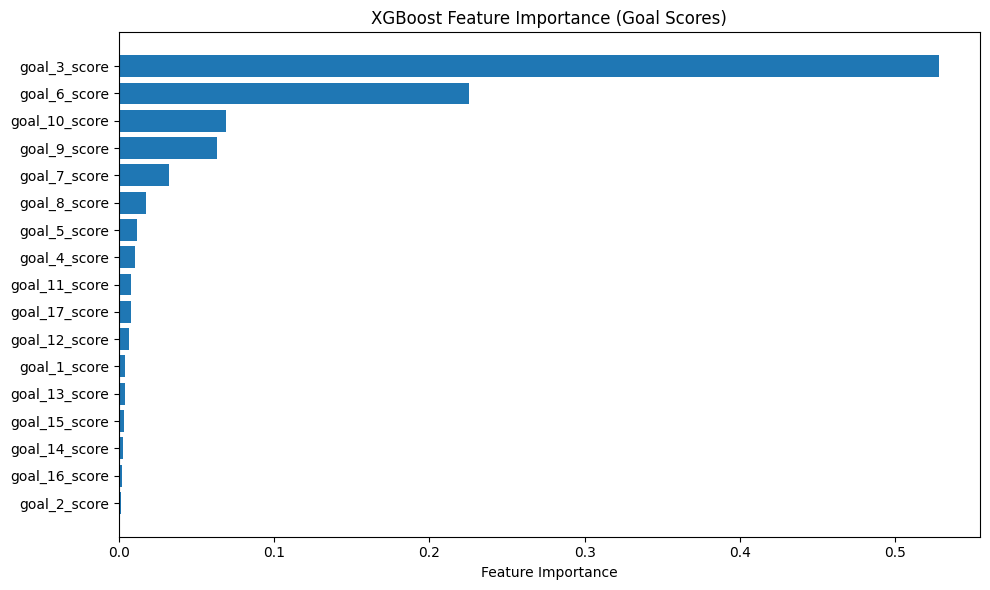

In [ ]:
# Plot XGBoost built-in feature importance
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Plot feature importances
plt.figure(figsize=(10, 6))
xgb_importances = xgb_model.feature_importances_
sorted_idx = xgb_importances.argsort()
plt.barh(X.columns[sorted_idx], xgb_importances[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance (Goal Scores)")
plt.tight_layout()
plt.show()

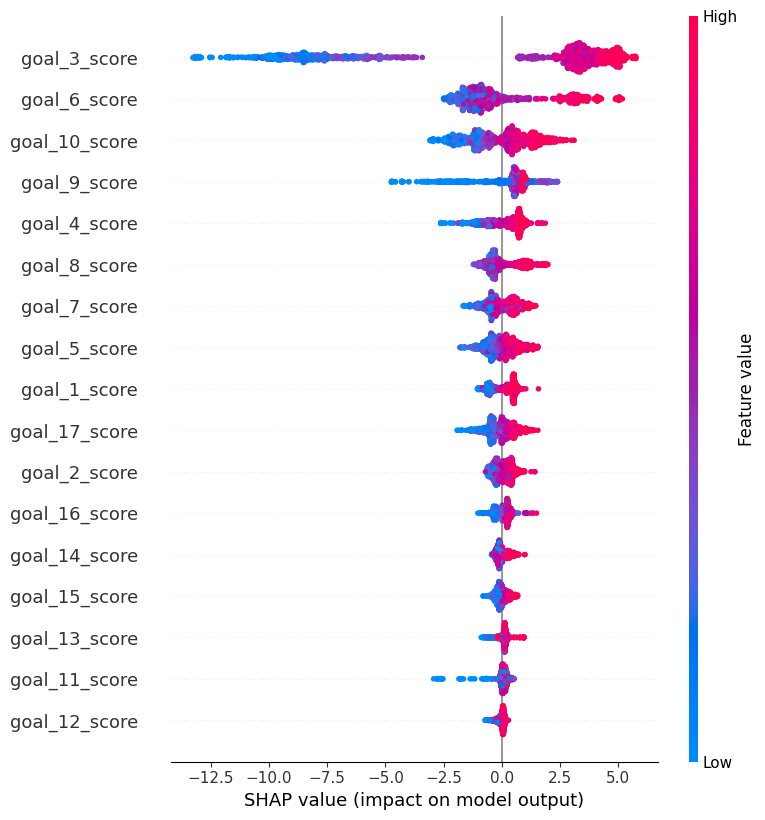

In [ ]:
# 1. Import required packages
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 2. Load your dataset
df = pd.read_csv("sdg_index_2000-2022.csv")
df = df[df['year'] >= 2015]  # keep only post-2015 data

# 3. Define features and target
goal_columns = [col for col in df.columns if 'goal_' in col and '_score' in col]
X = df[goal_columns]
y = df['sdg_index_score']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train XGBoost model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# 6. SHAP: Create explainer and get values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# 7. Plot SHAP summary (dot style)
shap.summary_plot(shap_values, X)


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Select important features
top5_features = ['goal_3_score', 'goal_6_score', 'goal_10_score', 'goal_9_score', 'goal_7_score']
X_top5 = df[top5_features]
y = df['sdg_index_score']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X_top5, y, test_size=0.2, random_state=42)

# XGBoost training
model_top5 = XGBRegressor(random_state=42)
model_top5.fit(X_train, y_train)

# prediction
y_pred = model_top5.predict(X_test)

# Print performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(" Model Performance (Top 5 Features)")
print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")

📊 Model Performance (Top 5 Features)
R² Score  : 0.9904
MAE       : 0.75
RMSE      : 1.03


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Create binary target
df['sdg_index_class'] = (df['sdg_index_score'] >= 80).astype(int)

# Top 5 features from SHAP/XGBoost
top5_features = ['goal_3_score', 'goal_6_score', 'goal_10_score', 'goal_9_score', 'goal_7_score']
X_cls = df[top5_features]
y_cls = df['sdg_index_class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Model training
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Output classification report
print(classification_report(y_test, y_pred, digits=2))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       268
           1       0.95      0.95      0.95        20

    accuracy                           0.99       288
   macro avg       0.97      0.97      0.97       288
weighted avg       0.99      0.99      0.99       288



# DBSCAN

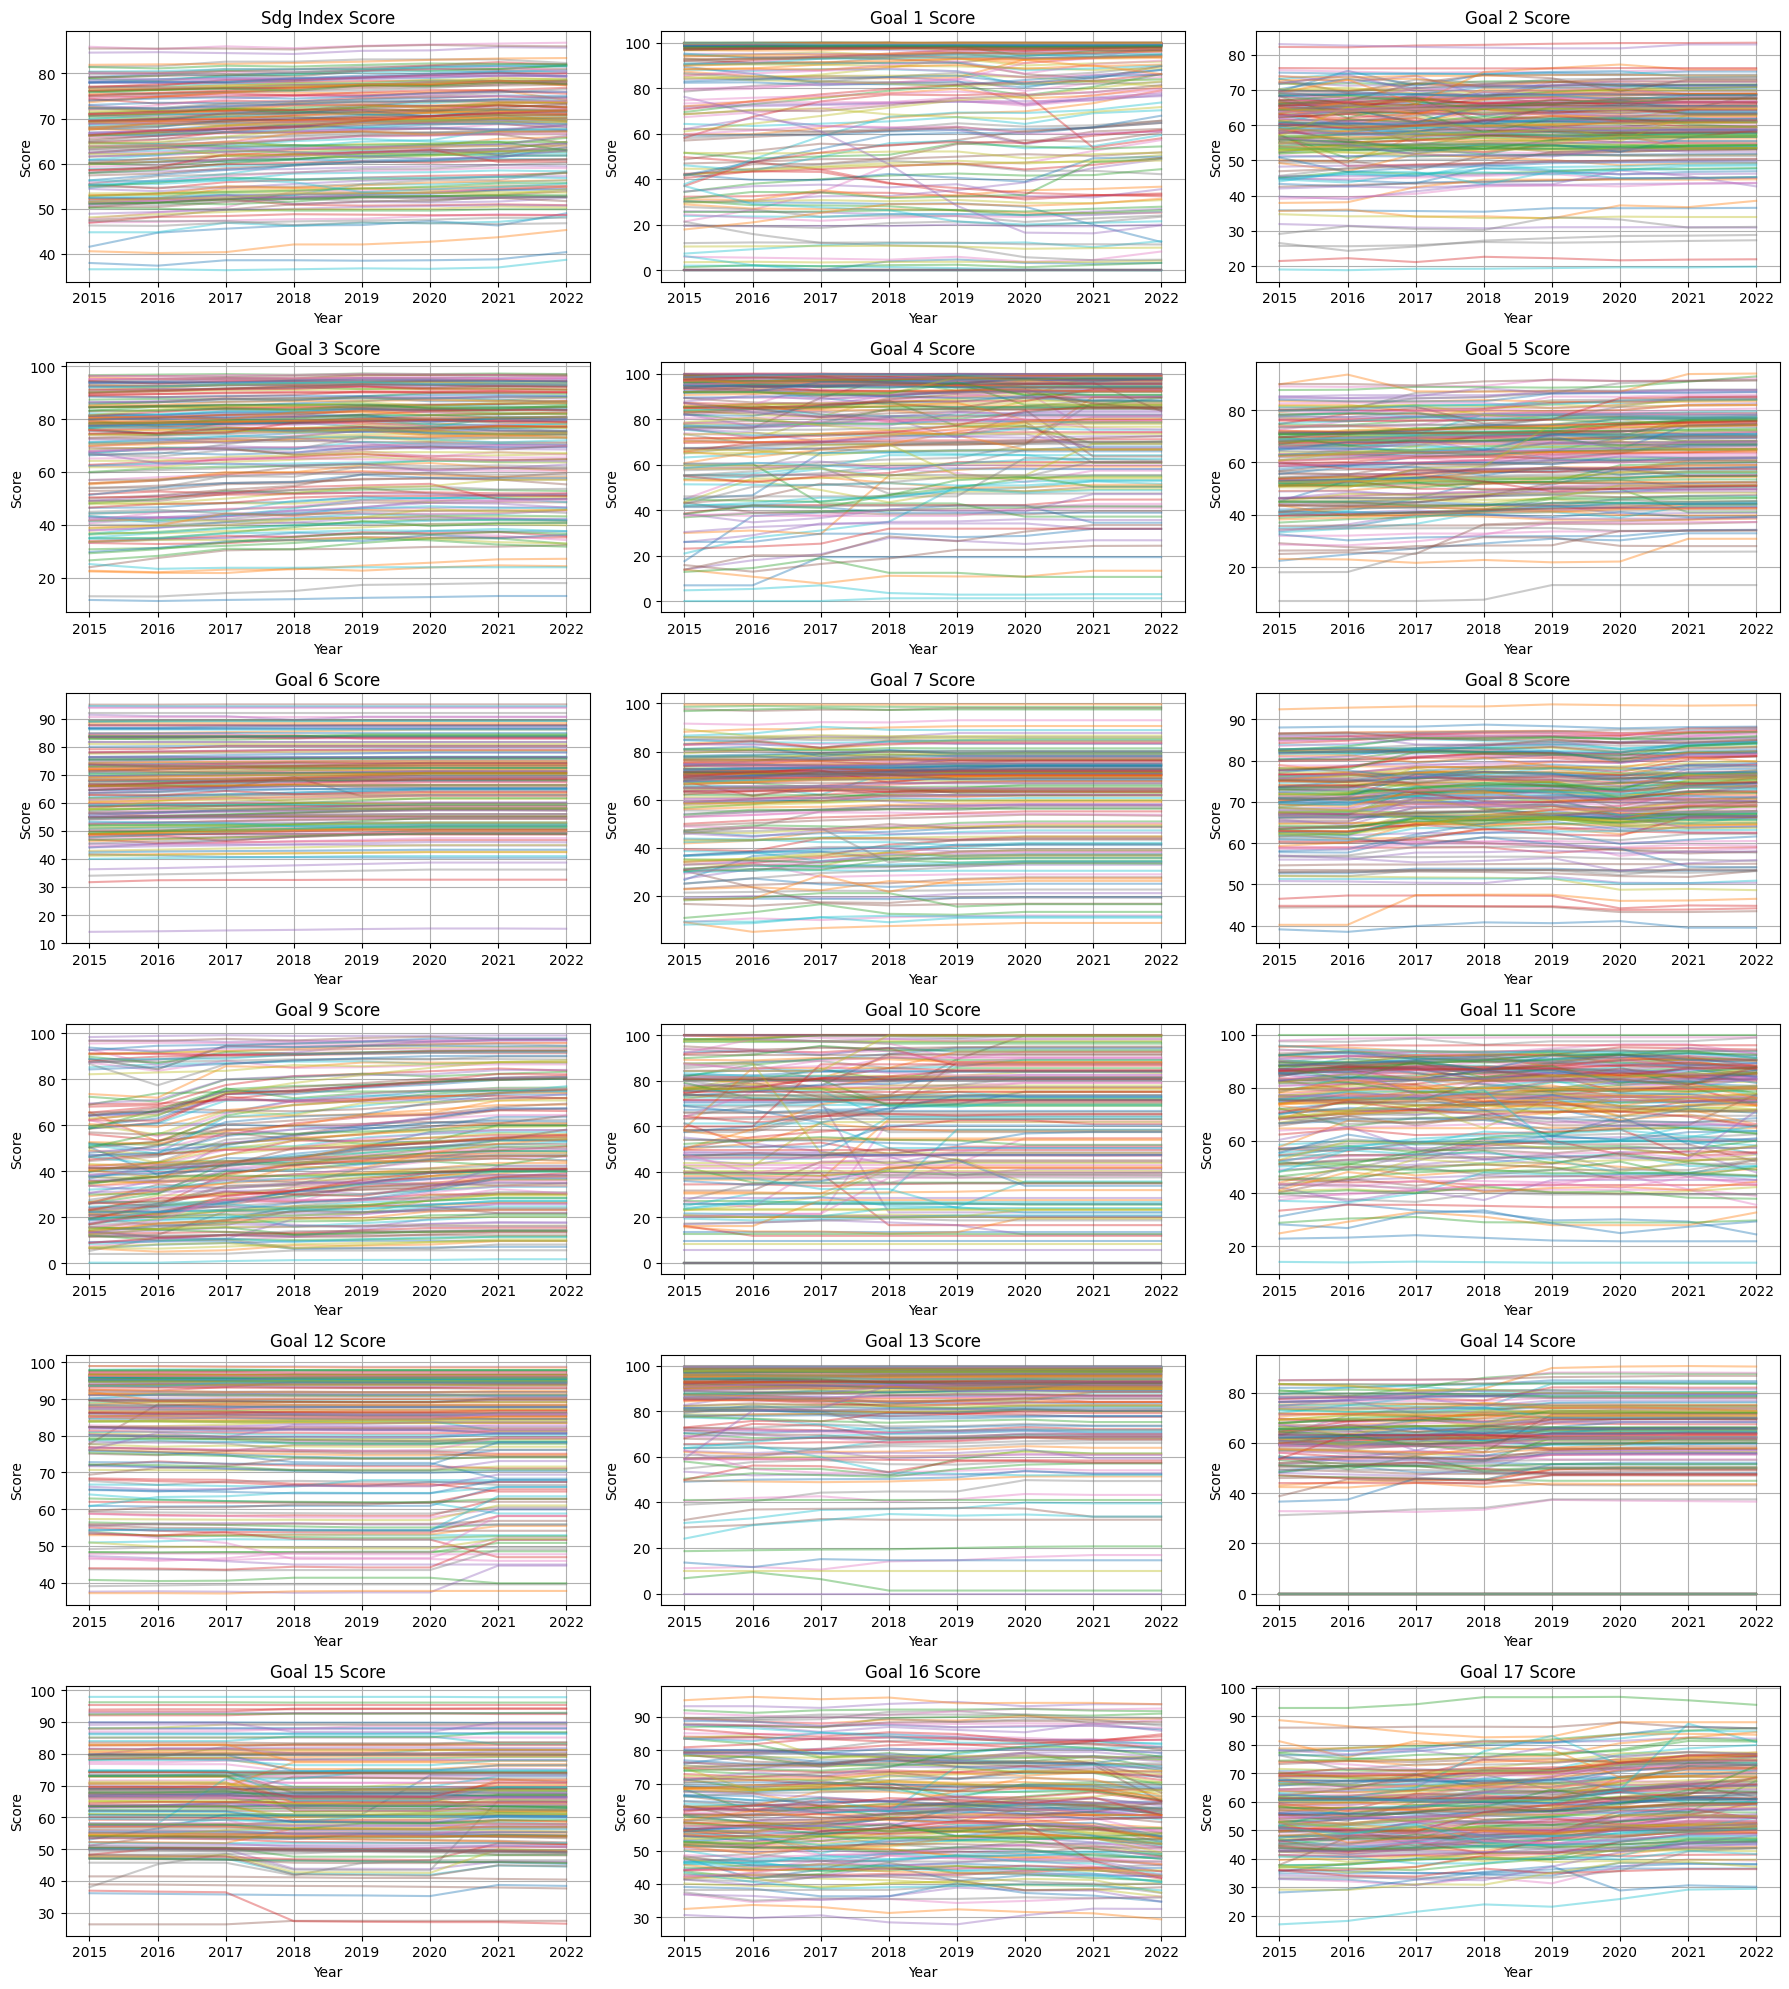

In [ ]:
import matplotlib.pyplot as plt

# Select only relevant columns and years
df_filtered = df[df['year'] >= 2015].copy()

# Define the list of SDG-related scores including overall index
score_columns = ['sdg_index_score'] + [col for col in df.columns if 'goal_' in col and '_score' in col]

# Set up the plots
num_scores = len(score_columns)
fig, axes = plt.subplots(nrows=(num_scores + 2) // 3, ncols=3, figsize=(18, 20))
axes = axes.flatten()

# Plot each score over time, with each country as one line
for i, score in enumerate(score_columns):
    ax = axes[i]
    for country, group in df_filtered.groupby('country'):
        ax.plot(group['year'], group[score], label=country, alpha=0.4)
    ax.set_title(score.replace('_', ' ').title())
    ax.set_xlabel('Year')
    ax.set_ylabel('Score')
    ax.grid(True)

# Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


In [ ]:
def cluster_and_plot_goal_time_series(df, goal_col, eps=1.5, min_samples=2):
    # Pivot: years as index, countries as columns
    pivot_df = df.pivot(index='year', columns='country', values=goal_col)

    # Drop countries with missing data
    data = pivot_df.T.dropna()
    ts_data = data.values
    country_names = data.index.tolist()

    # Normalize (mean-variance scaling)
    scaler = TimeSeriesScalerMeanVariance()
    ts_scaled = scaler.fit_transform(ts_data)

    # DTW distance matrix
    dist_matrix = cdist_dtw(ts_scaled)

    # Apply DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = db.fit_predict(dist_matrix)

    # Colors
    unique_labels = np.unique(labels)
    palette = sns.color_palette("hls", len(unique_labels))
    cluster_colors = {label: to_hex(color) for label, color in zip(unique_labels, palette)}

    # Plot
    fig = go.Figure()
    for idx, label in enumerate(labels):
        country = country_names[idx]
        y = ts_data[idx]
        color = 'lightgray' if label == -1 else cluster_colors[label]
        name = "Outlier" if label == -1 else f"Cluster {label}"
        legend_group = name
        show_legend = country_names.index(country) == list(labels).index(label)

        fig.add_trace(go.Scatter(
            x=pivot_df.index,
            y=y,
            mode='lines',
            name=name,
            line=dict(color=color),
            legendgroup=legend_group,
            showlegend=show_legend,
            hovertemplate=f"Country: {country}"
        ))

    fig.update_layout(
        title=f"Clustering of {goal_col.replace('_score', '').replace('_', ' ').title()} Time Series",
        xaxis_title="Year",
        yaxis_title="Score",
        showlegend=True,
        width=700,
        height=450
    )
    fig.show()

In [ ]:
cluster_and_plot_goal_time_series(df, goal_col='goal_3_score', eps=1.5, min_samples=2)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
cluster_and_plot_goal_time_series(df, goal_col='goal_6_score', eps=1.6, min_samples=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
cluster_and_plot_goal_time_series(df, goal_col='goal_7_score', eps=1, min_samples=3 )

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
cluster_and_plot_goal_time_series(df, goal_col='goal_9_score', eps=0.5, min_samples=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
cluster_and_plot_goal_time_series(df, goal_col='goal_10_score', eps=1.4, min_samples=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



#K-MEANS

In [ ]:
# Define the function again
def kmeans_cluster_and_plot_goal_time_series(df, goal_col, n_clusters=3):
    # Pivot: years as index, countries as columns
    pivot_df = df.pivot(index='year', columns='country', values=goal_col)

    # Drop countries with missing data
    data = pivot_df.T.dropna()
    ts_data = data.values
    country_names = data.index.tolist()

    # Normalize (mean-variance scaling)
    scaler = TimeSeriesScalerMeanVariance()
    ts_scaled = scaler.fit_transform(ts_data)

    # Flatten to 2D for KMeans
    ts_flat = ts_scaled.reshape(ts_scaled.shape[0], -1)

    # Apply KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(ts_flat)

    # Colors
    unique_labels = np.unique(labels)
    palette = sns.color_palette("tab10", len(unique_labels))
    cluster_colors = {label: to_hex(color) for label, color in zip(unique_labels, palette)}

    # Plot
    fig = go.Figure()
    for idx, label in enumerate(labels):
        country = country_names[idx]
        y = ts_data[idx]
        color = cluster_colors[label]
        name = f"Cluster {label}"
        legend_group = name
        show_legend = country_names.index(country) == list(labels).index(label)

        fig.add_trace(go.Scatter(
            x=pivot_df.index,
            y=y,
            mode='lines',
            name=name,
            line=dict(color=color),
            legendgroup=legend_group,
            showlegend=show_legend,
            hovertemplate=f"Country: {country}"
        ))

    fig.update_layout(
        title=f"KMeans Clustering of {goal_col.replace('_score', '').replace('_', ' ').title()} Time Series",
        xaxis_title="Year",
        yaxis_title="Score",
        showlegend=True,
        width=700,
        height=450
    )
    fig.show()

In [ ]:
kmeans_cluster_and_plot_goal_time_series(df, 'goal_3_score', n_clusters=5)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
kmeans_cluster_and_plot_goal_time_series(df, 'goal_6_score', n_clusters=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
kmeans_cluster_and_plot_goal_time_series(df, 'goal_7_score', n_clusters=4)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
kmeans_cluster_and_plot_goal_time_series(df, 'goal_9_score', n_clusters=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
kmeans_cluster_and_plot_goal_time_series(df, 'goal_10_score', n_clusters=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

